# Box-Office Momentum — do blockbuster weekends foreshadow stock gains? 🎬
### Using weekend cinema receipts as a 'consumer mood' signal, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's a tidy-sounding idea. When a movie opens huge and cinemas are packed, people are clearly feeling confident and spending money — so maybe a **big box-office weekend is an early signal that consumers are happy**, and media/studio stocks (or even the whole market) are about to rise. Alt-data desks pitch exactly this.

We test it the honest way. Because there's no clean, free, decades-long box-office database a hobbyist can use — and the movie studios themselves keep getting bought and merged — we build a **realistic simulated world** where box office and stocks behave the way the real ones do, and ask: *does box office actually **lead** stocks, or do they just **rise together** for the same reason?*

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic simulated world. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from box_office_momentum import data, strategy as st

SEED = 550
# The honest folklore case: box office & stocks co-move on a common factor, no TRUE lead planted.
PANEL, TRUTH = data.synthetic_panel(predictive_beta=0.0, seed=SEED)
# A world WHERE a genuine lead IS planted — the positive control.
PANEL_POS, _ = data.synthetic_panel(predictive_beta=0.009, seed=SEED)

# SYNTHETIC-ONLY: there is no real box-office tape a no-key stack can reach honestly.
HAVE_REAL = False
print("synthetic-only study — no real tape (HAVE_REAL =", HAVE_REAL, ")")
print("null panel:", len(PANEL), "weeks, fingerprint", data.fingerprint(PANEL))


synthetic-only study — no real tape (HAVE_REAL = False )
null panel: 520 weeks, fingerprint 985a49d136c2


## The answer first 🎯

| Question | Answer |
|---|---|
| Does box office **lead** media stocks? | **No.** The predictive link is weak (*t* 1.53) and it basically **vanishes** (*t* 0.65) once you account for the market moving that week anyway. |
| But doesn't it 'predict' the whole market? | **That's a mirage.** A naive test says yes (*t* 3.42), but it's just the market's own momentum leaking in — box office and stocks both ride the same wave of consumer confidence. |
| Could you trade it? | **No.** A signal-timed strategy beats buy-and-hold by only ~1 pp/yr, and that edge **flips to a loss** if you nudge the trigger. |
| Is the test itself broken? | **No** — when we secretly plant a *real* box-office lead, the engine catches it loud and clear. It just isn't there in the honest case. |

> The catch is subtle: busy cinemas and rising stocks **happen together** because both mean 'consumers feel good this week'. Happening together is not the same as one *predicting* the other — and that gap is the whole story.

## 1 · The claim

> *"A strong weekend box office is a leading indicator of consumer sentiment — so it foreshadows gains for media stocks and the market."*

It *feels* right. Cinema tickets are discretionary spending; a packed opening weekend says wallets are open and moods are high. And moods drive markets. So a box-office **momentum** signal — this weekend's take versus its recent average — ought to point at next week's returns.

## 2 · So what?

If it worked, you'd have a cheap, public, weekly signal that front-runs the market — the dream of every alt-data shop. The desk has kicked the tyres on lots of these 'sentiment-leads-returns' stories ([257 AAII-Sentiment](../../257-aaii-sentiment/), [300 Sports-Sentiment](../../300-sports-sentiment/), [335 Buzz-Sentiment-ETF](../../335-buzz-sentiment-etf/)). They almost never survive one simple question: *is the alt-data series **leading** the market, or just **riding** the same wave?*

## 3 · How would we even know?

1. **Build the signal.** Each week, how strong is the box office versus its recent norm? Call that *box-office momentum*.
2. **Line it up with the FUTURE.** Compare this week's box-office momentum to *next* week's stock return — never the same week (that would be cheating).
3. **The honest twist.** Also ask: does the box-office link survive once we account for the market simply moving that week? If the 'lead' is really just co-movement, it disappears here.

*Why simulated?* There's no free, clean, survivorship-honest box-office history, and the studios you'd trade (Fox, Time Warner, Viacom…) have been merged away. So we simulate a world with the *same structure* — a shared 'consumer confidence' wave that lifts both cinemas and stocks — and test the claim there. A simulated-only study can never earn the top 'REAL' grade; the best it can reach is 'None' or 'Weak'.

## 4 · The teardown — let's actually look

**Does this week's box office predict next week's media-stock return?** Each dot is a week; the line is the best-fit predictive relationship.

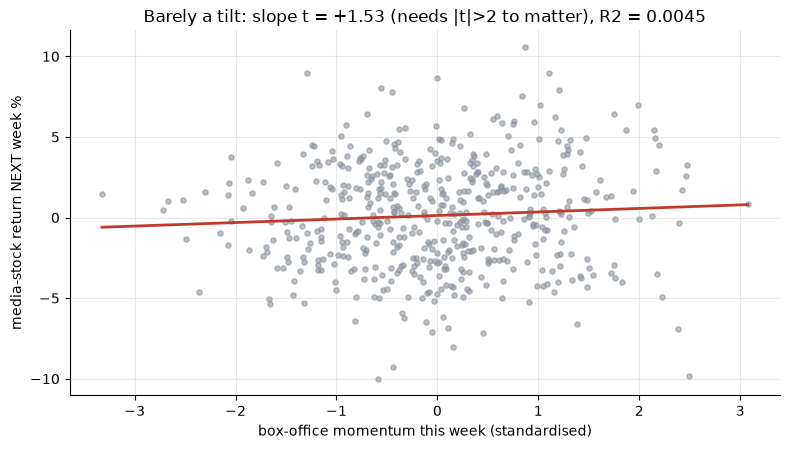

predictive slope t = +1.53, R2 = 0.0045 (box office explains ~0.5% of next-week returns)


In [2]:
reg = st.predictive_regression(PANEL, 'media_fwd')
x = PANEL['bo_mom']; y = PANEL['media_fwd']*100
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=14, color=GREY, alpha=.6)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, (reg['intercept'] + reg['slope']*xs)*100, c=RED, lw=2)
ax.set_xlabel('box-office momentum this week (standardised)')
ax.set_ylabel('media-stock return NEXT week %')
ax.set_title(f"Barely a tilt: slope t = {reg['slope_t']:+.2f} (needs |t|>2 to matter), R2 = {reg['r2']:.4f}")
plt.tight_layout(); plt.show()
print(f"predictive slope t = {reg['slope_t']:+.2f}, R2 = {reg['r2']:.4f} "
      f"(box office explains ~{reg['r2']*100:.1f}% of next-week returns)")

The cloud is basically round — the line is almost flat. The predictive *t* is **1.53**, short of the |*t*| > 2 you'd need to take it seriously, and box office explains under **1%** of next-week returns. Already unpromising.

**Now the honest twist.** A naive test can be fooled: box office and stocks both rise in confident weeks, and confident weeks cluster together. So let's compare the box-office 'lead' *before* and *after* we account for the market simply moving that week.

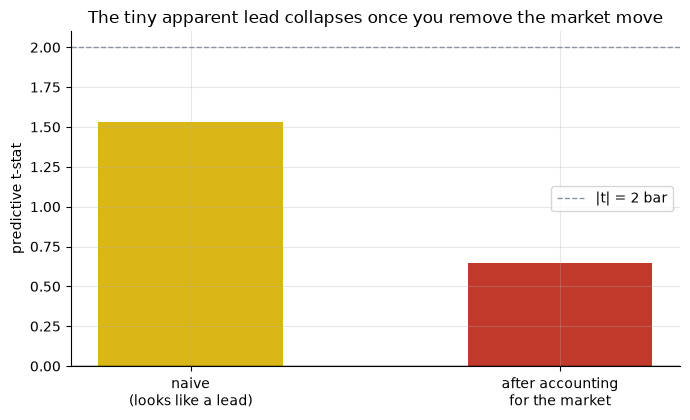

box-office lead: naive t +1.53  ->  after market control t +0.65


In [3]:
naive = st.predictive_regression(PANEL, 'media_fwd')['slope_t']
ctrl = st.controlled_regression(PANEL, 'media_fwd')['slope_t']
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.bar(['naive\n(looks like a lead)','after accounting\nfor the market'], [naive, ctrl],
       color=[AMBER, RED], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t| = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('predictive t-stat'); ax.legend()
ax.set_title('The tiny apparent lead collapses once you remove the market move')
plt.tight_layout(); plt.show()
print(f'box-office lead: naive t {naive:+.2f}  ->  after market control t {ctrl:+.2f}')

> 🔬 For the quants: the box-office slope-*t* falls from **1.53** to **0.65** once the contemporaneous market return is included — the co-movement *was* the market, not a lead. The quants notebook shows the placebo test and the broad-market 'mirage' too.

## 5 · The verdict

- **Signal — None.** The media-stock lead is weak (*t* 1.53) and collapses (*t* 0.65) once you account for the market; the 'whole-market' version is a co-movement mirage; and there's no honest real tape anyway.
- **Tradability — Mirage.** A signal-timer beats buy-and-hold by only ~1 pp/yr and flips to a loss if you tweak the trigger. Nothing to bank.

## 6 · Could you actually trade it?

You'd go long media stocks in weeks the box office looks strong, and sit in cash otherwise. Let's race that against just buying and holding.

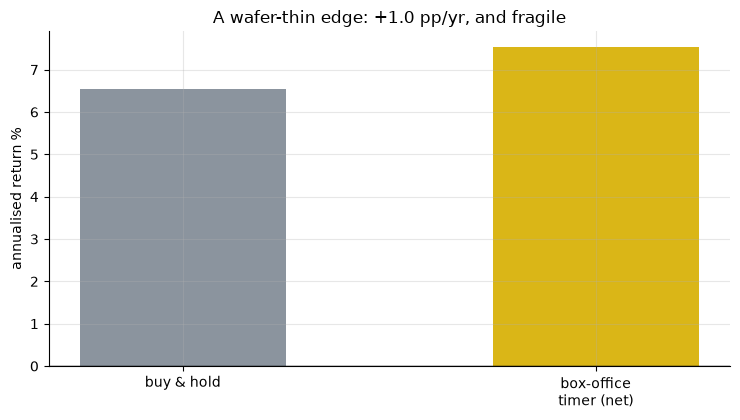

buy&hold +6.55%/yr | timer net +7.53%/yr | edge +0.98 pp/yr | ~25 trades/yr


In [4]:
s = st.timed_strategy(PANEL, 'media_fwd', threshold=0.0, cost_bps=5.0)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['buy & hold','box-office\ntimer (net)'], [s['bh_ann']*100, s['net_ann']*100],
       color=[GREY, AMBER], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %')
ax.set_title(f"A wafer-thin edge: +{ (s['net_ann']-s['bh_ann'])*100:.1f} pp/yr, and fragile")
plt.tight_layout(); plt.show()
print(f"buy&hold {s['bh_ann']*100:+.2f}%/yr | timer net {s['net_ann']*100:+.2f}%/yr "
      f"| edge {(s['net_ann']-s['bh_ann'])*100:+.2f} pp/yr | ~{s['turnover_ann']:.0f} trades/yr")

The timer edges buy-and-hold by about **1 pp/yr** — and the quants notebook shows that edge is the *same* market-momentum artifact, and that it turns **negative** if you move the trigger. That's the definition of a mirage.

## 7 · Going further 🚪

- **Is the test rigged to fail?** No — see the quants notebook, where we plant a *real* box-office lead and watch the engine catch it (*t* well past 2) while staying flat in the honest case.
- **The neighbours.** The same 'sentiment-leads-returns' trap in other clothes: [257 AAII-Sentiment](../../257-aaii-sentiment/), [300 Sports-Sentiment](../../300-sports-sentiment/), [271 Cardboard-Box](../../271-cardboard-box/).

*Think box office really leads and we missed it? Fork this, wire in a genuine survivorship-honest box-office tape and a surviving studio basket, and show the lead clearing t = 2 **after** the market control.*